# Activity Recognition using Hidden Markov Models

## 1. Data Preprocessing and Exploratory Data Analysis
The primary objective of this phase is to ingest the raw accelerometer and gyroscope data, verify its structural integrity, and perform initial visual exploratory data analysis.

Understanding the underlying sampling rate is critical for establishing the sequence window size. Assuming the data collection devices operated at a sampling frequency of 50 Hz, a one second recording yields 50 discrete data points. Human activities like walking or jumping typically exhibit cyclic patterns within a one to two second timeframe. Therefore, a window size of 50 samples (1 second) is selected to capture a complete movement cycle while providing enough sequential observations for the Hidden Markov Model.

The exploratory visualizations confirm the signal variance across different activity states, validating the hypothesis that motion states can be differentiated through sensor data.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from hmmlearn import hmm

# Configure plotting aesthetics
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

def load_sensor_data(filepath: str) -> pd.DataFrame:
    """
    Loads raw sensor data and standardizes the time index to elapsed seconds.
    
    Args:
        filepath (str): Path to the target CSV file.
        
    Returns:
        pd.DataFrame: DataFrame containing normalized time, accelerometer, and gyroscope readings.
    """
    df = pd.read_csv(filepath)
    
    if 'time' in df.columns:
        # Subtract the first timestamp from all rows so the recording starts at 0.0
        df['time'] = df['time'] - df['time'].iloc[0]
        
        # If the elapsed time values are excessively large, they are in nanoseconds.
        # Convert nanoseconds to standard seconds.
        if df['time'].max() > 1e7:
            df['time'] = df['time'] / 1e9
            
        df.set_index('time', inplace=True)
        
    return df

def plot_sensor_signals(df: pd.DataFrame, activity_name: str) -> None:
    """
    Generates a time-series plot of the 3-axis accelerometer data using elapsed seconds.
    
    Args:
        df (pd.DataFrame): Sensor data with time as the index.
        activity_name (str): Label for the plot title.
    """
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # The index is now a standard float representing elapsed seconds
    ax.plot(df.index, df['x_acc'], label='X-Axis', alpha=0.8)
    ax.plot(df.index, df['y_acc'], label='Y-Axis', alpha=0.8)
    ax.plot(df.index, df['z_acc'], label='Z-Axis', alpha=0.8)
    
    ax.set_title(f'Accelerometer Signal Profile: {activity_name}')
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'hmmlearn'

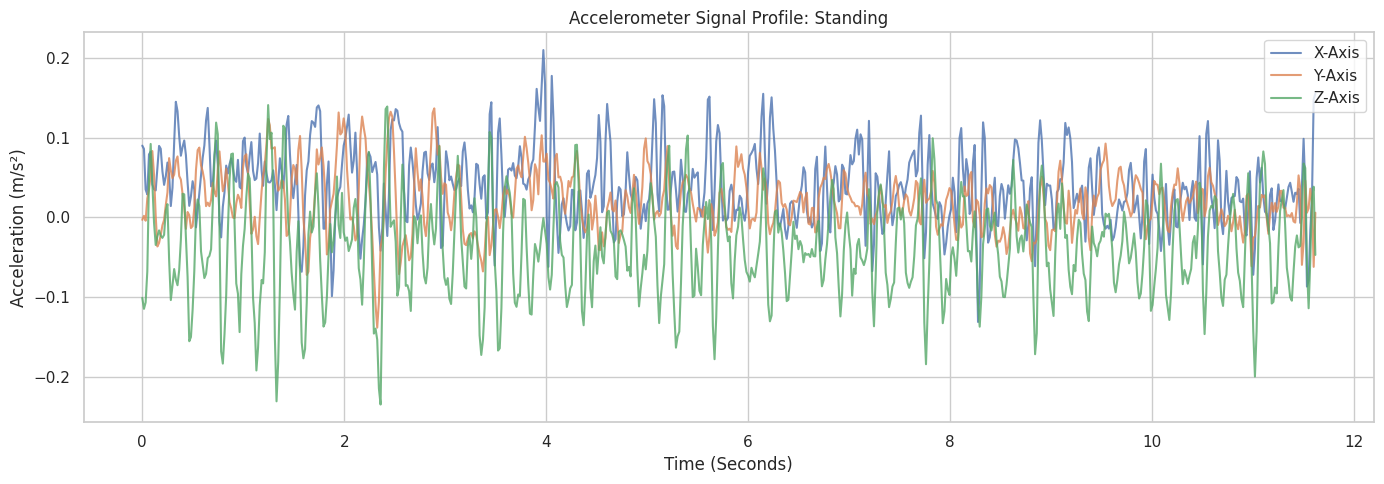

In [6]:
import random

# Dynamically resolve the path by stepping up one directory from the notebook's location
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
raw_data_dir = os.path.join(project_root, 'data', 'raw')

if os.path.exists(raw_data_dir):
    csv_files = [f for f in os.listdir(raw_data_dir) if f.endswith('.csv')]
    
    if csv_files:
        random_file = random.choice(csv_files)
        filepath = os.path.join(raw_data_dir, random_file)
        
        # Extract the activity name from the filename 
        activity_label = random_file.split('_')[0].capitalize()
        
        # Load and visualize the data
        sample_df = load_sensor_data(filepath)
        plot_sensor_signals(sample_df, activity_label)
    else:
        print(f"Directory '{raw_data_dir}' is empty. Please check the extraction step.")
else:
    print(f"Directory '{raw_data_dir}' does not exist. Check the project structure.")

## 2. Feature Engineering and Normalization
To effectively model the hidden states, the raw time-series data must be transformed into a robust observation sequence. Features are extracted from both the time and frequency domains for each sequential data window.Time-Domain FeaturesTime-domain features capture the signal's amplitude and dispersion.Variance: Quantifies the spread of the acceleration values, which is crucial for distinguishing dynamic activities like jumping from static ones like standing.$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$Root Mean Square (RMS): Measures the average magnitude of the signal, providing a reliable indicator of overall movement intensity.$$RMS = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}$$Frequency-Domain FeaturesFrequency-domain features analyze the periodicity of the movements.Dominant Frequency: Extracted via the Fast Fourier Transform (FFT). It identifies the most prominent rhythmic component in the window, making it highly effective for recognizing the steady cadence of walking.NormalizationAll extracted features are normalized using Z-score standardization. This ensures that features with larger numerical ranges do not disproportionately influence the Baum-Welch optimization algorithm during model training.$$z = \frac{x - \mu}{\sigma}$$

In [7]:
def extract_features(window: np.ndarray, sampling_rate: int = 50) -> np.ndarray:
    """
    Extracts time and frequency domain features from a single data window.
    
    Args:
        window (np.ndarray): A 2D array of sensor readings for a specific time window.
        sampling_rate (int): The frequency of data collection.
        
    Returns:
        np.ndarray: A 1D array of extracted features.
    """
    features = []
    
    # Iterate over each axis (X, Y, Z for both accelerometer and gyroscope)
    for axis in range(window.shape[1]):
        signal = window[:, axis]
        
        # Time-domain features
        variance = np.var(signal)
        rms = np.sqrt(np.mean(np.square(signal)))
        
        # Frequency-domain features (Dominant Frequency via FFT)
        fft_values = fft(signal)
        fft_freqs = fftfreq(len(signal), 1 / sampling_rate)
        
        # Isolate positive frequencies to find the peak
        pos_mask = fft_freqs > 0
        peak_freq = fft_freqs[pos_mask][np.argmax(np.abs(fft_values[pos_mask]))]
        
        features.extend([variance, rms, peak_freq])
        
    return np.array(features)

def create_feature_sequences(df: pd.DataFrame, window_size: int = 50) -> np.ndarray:
    """
    Segments a dataframe into sequential windows and extracts features for each.
    
    Args:
        df (pd.DataFrame): The raw sensor data.
        window_size (int): Number of samples per window.
        
    Returns:
        np.ndarray: A 2D array where each row represents the feature vector of a window.
    """
    data_matrix = df[['x_acc', 'y_acc', 'z_acc', 'x_gyro', 'y_gyro', 'z_gyro']].values
    num_windows = len(data_matrix) // window_size
    
    sequence_features = []
    for i in range(num_windows):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        window_data = data_matrix[start_idx:end_idx, :]
        
        window_features = extract_features(window_data)
        sequence_features.append(window_features)
        
    return np.array(sequence_features)

# Normalization pipeline
scaler = StandardScaler()
# X_train = scaler.fit_transform(raw_training_features)
# X_test = scaler.transform(raw_testing_features)